### This script will give per patch zero shot classification statistics

## TCGA

[OK] Patch statistics saved → D:\Aamir Gulzar\KSA_project2\Cancer-detection-classifier\Analysis_and_Visualization\Results\TCGA_Zeroshot_Statistics\patch_class_statistics_tcga.csv
label  patch_count  percentage  unique_patients  mean_score  std_score  min_score  max_score
  PDC       221885       16.10              412      0.4219     0.0860     0.0596     0.7683
  MUS       219058       15.90              415      0.5142     0.1071     0.0774     0.8502
  ADE       202508       14.70              409      0.4443     0.0778     0.0826     0.7510
  STR       147863       10.73              416      0.4231     0.0851     0.0844     0.7556
  MUC       118878        8.63              415      0.5048     0.1063     0.0483     0.8333
  ADI       102669        7.45              351      0.5876     0.1278     0.0696     0.8667
  CAR        80662        5.85              409      0.4641     0.0703     0.1455     0.7523
  LYM        66564        4.83              414      0.4482     0.1015     0.

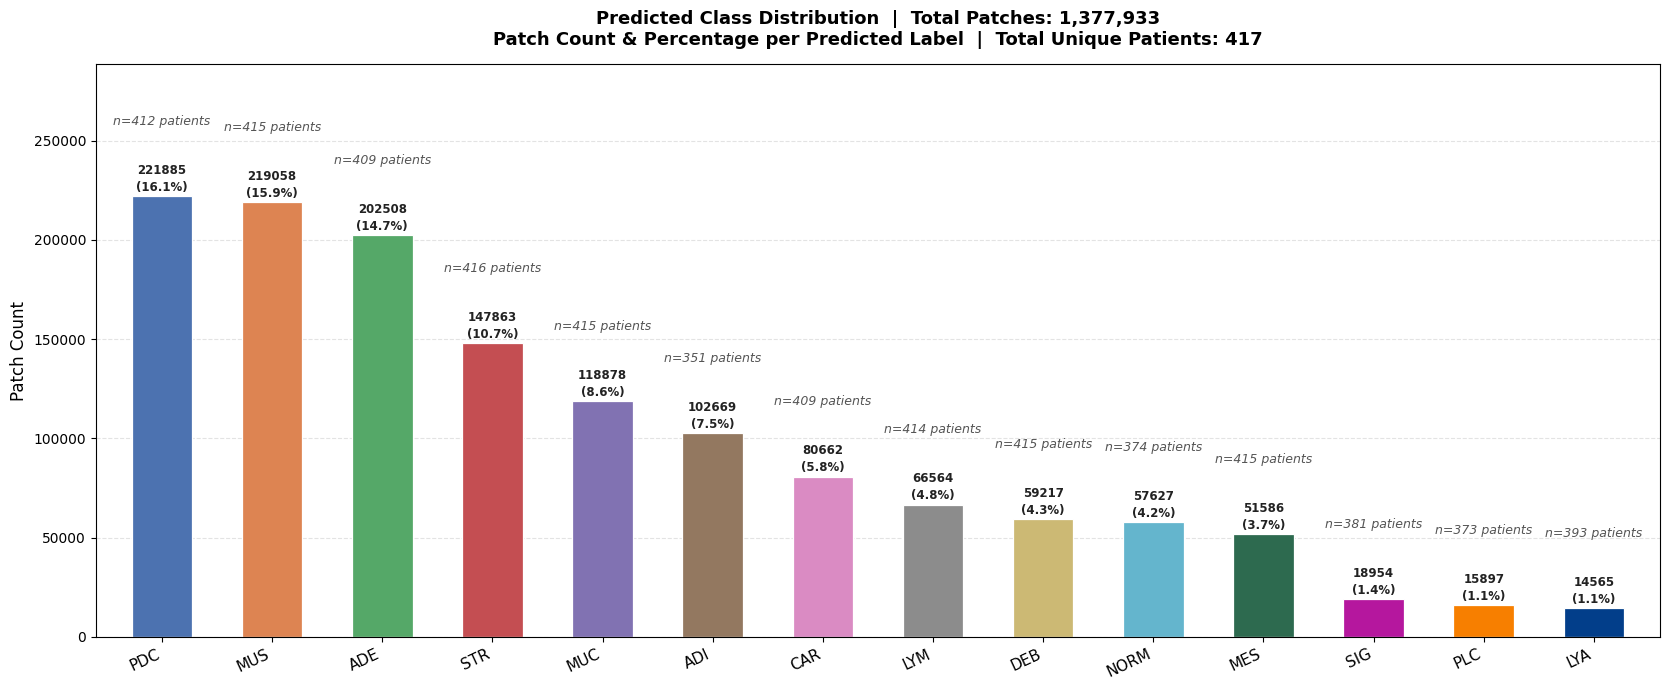

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

# ── Configuration ─────────────────────────────────────────────────────────────
INPUT_CSV  = r"D:\Aamir Gulzar\KSA_project2\Cancer-detection-classifier\slide_aggregation\caption_generation\Results\classification_results_tcga.csv"
OUTPUT_CSV = r"D:\Aamir Gulzar\KSA_project2\Cancer-detection-classifier\Analysis_and_Visualization\Results\TCGA_Zeroshot_Statistics\patch_class_statistics_tcga.csv"
OUTPUT_PNG = r"D:\Aamir Gulzar\KSA_project2\Cancer-detection-classifier\Analysis_and_Visualization\Results\TCGA_Zeroshot_Statistics\patch_class_statistics_tcga.png"

PATCH_ID_COL = "patch_name"

BAR_PALETTE = [
    "#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2",
    "#937860", "#DA8BC3", "#8C8C8C", "#CCB974", "#64B5CD",
    "#2d6a4f", "#b5179e", "#f77f00", "#023e8a",
]

# ── Load data ─────────────────────────────────────────────────────────────────
df = pd.read_csv(INPUT_CSV, sep=None, engine="python")

# ── Extract patient ID (first token before underscore) ────────────────────────
df["patient_id"] = df[PATCH_ID_COL].apply(lambda x: str(x).split("_")[0])

total_patches  = len(df)
total_patients = df["patient_id"].nunique()

# ── PATCH-LEVEL statistics ────────────────────────────────────────────────────
stats = (
    df.groupby("label")
    .agg(
        patch_count=("label", "count"),
        mean_score=("score", "mean"),
        std_score=("score", "std"),
        min_score=("score", "min"),
        max_score=("score", "max"),
    )
    .reset_index()
    .sort_values("patch_count", ascending=False)
)
stats["percentage"] = (stats["patch_count"] / total_patches * 100).round(2)
for col in ["mean_score", "std_score", "min_score", "max_score"]:
    stats[col] = stats[col].round(4)

# ── Per-class unique patient counts (any patient with ≥1 patch of that class) ─
patients_per_class = (
    df.groupby("label")["patient_id"]
    .nunique()
    .reset_index()
    .rename(columns={"patient_id": "unique_patients"})
)
stats = stats.merge(patients_per_class, on="label", how="left")

stats = stats[["label", "patch_count", "percentage", "unique_patients",
               "mean_score", "std_score", "min_score", "max_score"]]

total_row = pd.DataFrame([{
    "label": "TOTAL", "patch_count": total_patches, "percentage": 100.0,
    "unique_patients": total_patients,
    "mean_score": df["score"].mean().round(4), "std_score": df["score"].std().round(4),
    "min_score": df["score"].min().round(4), "max_score": df["score"].max().round(4),
}])
stats_out = pd.concat([stats, total_row], ignore_index=True)
stats_out.to_csv(OUTPUT_CSV, index=False)
print(f"[OK] Patch statistics saved → {OUTPUT_CSV}")
print(stats_out.to_string(index=False))

# ── Plot patch distribution with patient counts on top ────────────────────────
def make_bar_chart(series_labels, series_counts, series_pct, series_patients,
                   total, title, ylabel, out_path):
    x      = np.arange(len(series_labels))
    colors = [BAR_PALETTE[i % len(BAR_PALETTE)] for i in range(len(series_labels))]
    bar_w  = 0.55

    fig, ax = plt.subplots(figsize=(max(10, len(series_labels) * 1.2), 7))
    bars = ax.bar(x, series_counts, width=bar_w, color=colors,
                  edgecolor="white", linewidth=0.9, zorder=2)

    y_max = max(series_counts)

    for xi, cnt, pct, n_patients in zip(x, series_counts, series_pct, series_patients):
        # Line 1: patch count + percentage
        # Line 2: patient count (slightly smaller, muted color)
        label_text = f"{int(cnt)}\n({pct:.1f}%)\n{int(n_patients)} pts"
        ax.text(
            xi,
            cnt + y_max * 0.005,
            f"{int(cnt)}\n({pct:.1f}%)",
            ha="center", va="bottom",
            fontsize=8.5, fontweight="bold",
            color="#222222", zorder=3, linespacing=1.4,
        )
        # Patient count written just above the patch count label
        # We stack it on top by computing cumulative height
        line_height = y_max * 0.075  # approx height of 2 text lines
        ax.text(
            xi,
            cnt + y_max * 0.005 + line_height * 2,
            f"n={int(n_patients)} patients",
            ha="center", va="bottom",
            fontsize=9.0, fontweight="normal",
            color="#555555", zorder=3,
            style="italic",
        )

    ax.set_xticks(x)
    ax.set_xticklabels(series_labels, fontsize=11, rotation=25, ha="right")
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_ylim(0, y_max * 1.30)   # extra headroom for the patient label
    ax.set_xlim(-0.6, len(series_labels) - 0.4)
    ax.set_title(title, fontsize=13, fontweight="bold", pad=14)
    ax.yaxis.grid(True, linestyle="--", alpha=0.35, zorder=0)
    ax.set_axisbelow(True)
    fig.tight_layout()
    fig.savefig(out_path, dpi=150, bbox_inches="tight")
    print(f"[OK] Chart saved → {out_path}")
    plt.show()

make_bar_chart(
    stats["label"].tolist(),
    stats["patch_count"].tolist(),
    stats["percentage"].tolist(),
    stats["unique_patients"].tolist(),
    total=total_patches,
    title=(
        f"Predicted Class Distribution  |  Total Patches: {total_patches:,}\n"
        f"Patch Count & Percentage per Predicted Label  |  Total Unique Patients: {total_patients:,}"
    ),
    ylabel="Patch Count",
    out_path=OUTPUT_PNG,
)

## CRC100K

[SKIP] Raw predictions already exist: Results\CRC100K_ZeroShot_Statistics\crc100k_raw_predictions.csv
       Delete the file to re-run classification.

Total patches: 100000
Statistics saved → Results\CRC100K_ZeroShot_Statistics\patch_class_statistics.csv
gt_label         verdict  patch_count  pct_within_gt  pct_of_total
     ADI         correct        10186          97.88         10.19
     ADI correct_subtype            0           0.00          0.00
     ADI       incorrect          221           2.12          0.22
    BACK         correct            0           0.00          0.00
    BACK correct_subtype            0           0.00          0.00
    BACK       incorrect        10566         100.00         10.57
     DEB         correct        10581          91.91         10.58
     DEB correct_subtype            0           0.00          0.00
     DEB       incorrect          931           8.09          0.93
     LYM         correct        10476          90.65         10.48
     LY

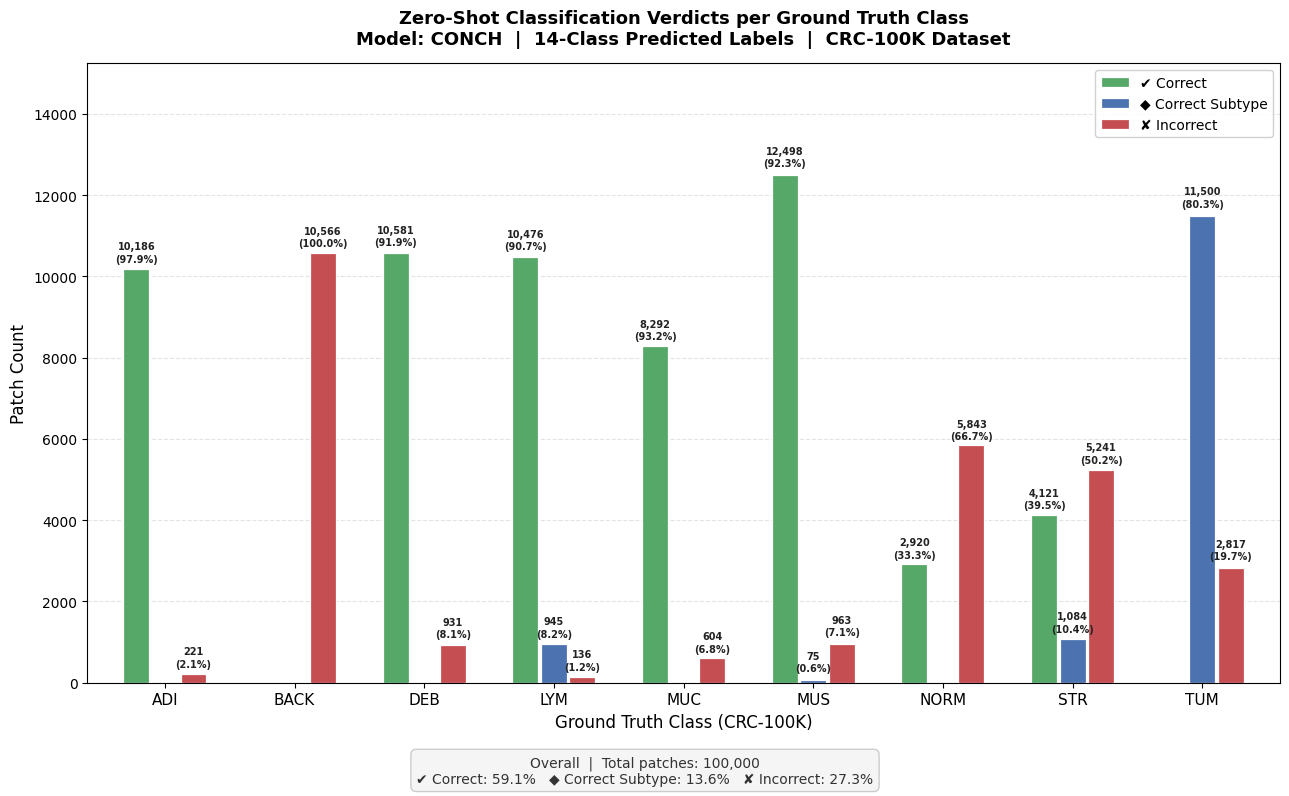

Heatmap saved → Results\CRC100K_ZeroShot_Statistics\gt_to_pred_heatmap.png


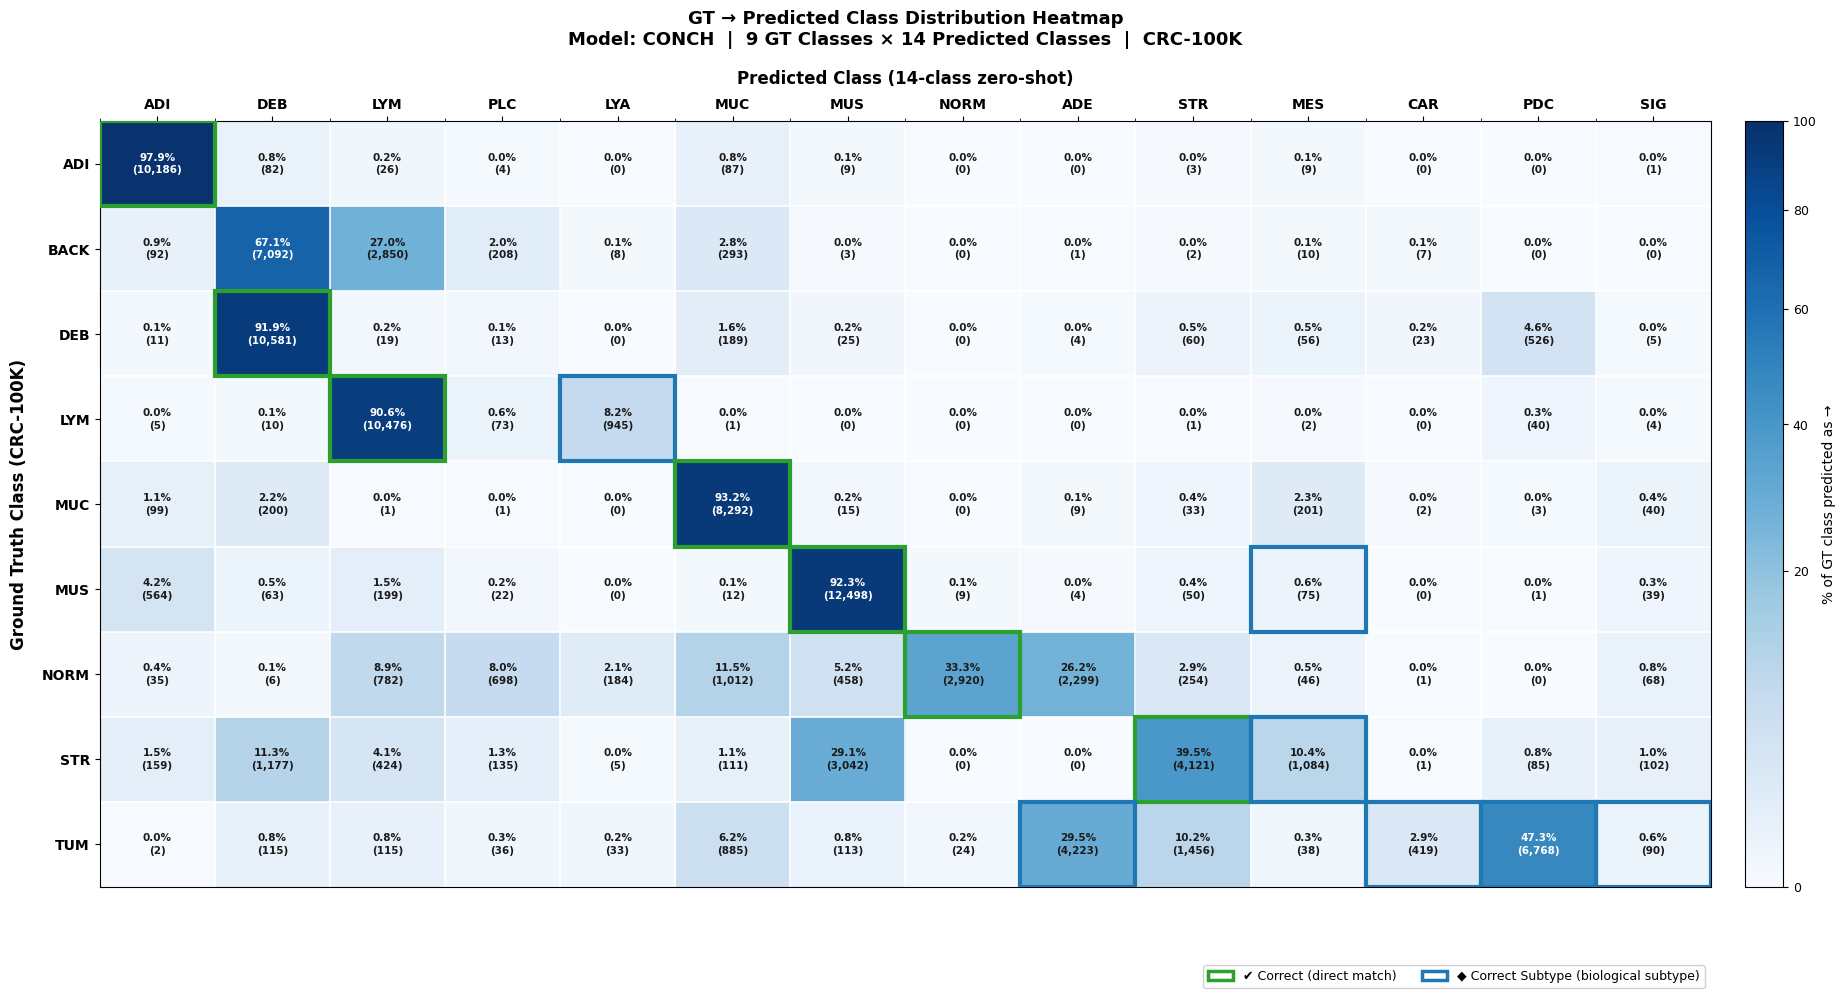

In [2]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import torch
from PIL import Image
from tqdm import tqdm
from pathlib import Path
from conch.open_clip_custom import create_model_from_pretrained
from conch.downstream.zeroshot_path import zero_shot_classifier

# ═══════════════════════════════════════════════════════════════════════════════
# CONFIGURATION  — update these paths
# ═══════════════════════════════════════════════════════════════════════════════
MAIN_FOLDER     = r"D:\Aamir Gulzar\dataset\CRC100K\NCT-CRC-HE-100K-NONORM"
CHECKPOINT_PATH = r"D:\Aamir Gulzar\KSA_project2\Cancer-detection-classifier\slide_aggregation\caption_generation\checkpoints\CONCH\pytorch_model.bin"
PROMPT_FILE     = r"D:\Aamir Gulzar\KSA_project2\Cancer-detection-classifier\slide_aggregation\caption_generation\config_files\Custom_prompts_all_per_class.json"
WEIGHTS_PATH    = r"D:\Aamir Gulzar\KSA_project2\Cancer-detection-classifier\slide_aggregation\caption_generation\classifier_weights\Conch_zeroshot_weights.pt"

OUTPUT_DIR      = r"Results\CRC100K_ZeroShot_Statistics"
RAW_CSV         = os.path.join(OUTPUT_DIR, "crc100k_raw_predictions.csv")
STATS_CSV       = os.path.join(OUTPUT_DIR, "patch_class_statistics.csv")
CHART_PNG       = os.path.join(OUTPUT_DIR, "patch_class_statistics.png")
HEATMAP_PNG     = os.path.join(OUTPUT_DIR, "gt_to_pred_heatmap.png")

FORCE_IMAGE_SIZE = 224
SAVE_EVERY       = 10_000

# ═══════════════════════════════════════════════════════════════════════════════
# CLASS DEFINITIONS
# ═══════════════════════════════════════════════════════════════════════════════
# 9 CRC-100K ground-truth classes (rows of the heatmap)
GT_CLASSES = ["ADI", "BACK", "DEB", "LYM", "MUC", "MUS", "NORM", "STR", "TUM"]

# 14 zero-shot predicted classes (columns of the heatmap)
PRED_CLASSES = ["ADI", "DEB", "LYM", "PLC", "LYA", "MUC", "MUS", "NORM",
                "ADE", "STR", "MES", "CAR", "PDC", "SIG"]

# ── Verdict maps ──────────────────────────────────────────────────────────────
CORRECT_MAP = {
    "ADI":  {"ADI"},
    "BACK": set(),
    "DEB":  {"DEB"},
    "LYM":  {"LYM"},
    "MUC":  {"MUC"},
    "MUS":  {"MUS"},
    "NORM": {"NORM"},
    "STR":  {"STR"},
    "TUM":  set(),
}

SUBTYPE_MAP = {
    "ADI":  set(),
    "BACK": set(),
    "DEB":  set(),
    "LYM":  {"LYA"},
    "MUC":  set(),
    "MUS":  {"MES"},
    "NORM": set(),
    "STR":  {"MES"},
    "TUM":  {"CAR", "PDC", "ADE", "SIG"},
}


def get_verdict(gt_label, pred_label):
    """Return 'correct', 'correct_subtype', or 'incorrect'."""
    gt   = gt_label.upper()
    pred = pred_label.upper()
    if pred in CORRECT_MAP.get(gt, set()):
        return "correct"
    if pred in SUBTYPE_MAP.get(gt, set()):
        return "correct_subtype"
    return "incorrect"


# ═══════════════════════════════════════════════════════════════════════════════
# STEP 1 — RUN ZERO-SHOT CLASSIFICATION (skip if RAW_CSV already exists)
# ═══════════════════════════════════════════════════════════════════════════════
def run_classification():
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    model, preprocess = create_model_from_pretrained(
        model_cfg="conch_ViT-B-16",
        checkpoint_path=CHECKPOINT_PATH,
        device=device,
        force_image_size=FORCE_IMAGE_SIZE,
    )
    model.eval()

    with open(PROMPT_FILE) as f:
        prompt_data = json.load(f)["0"]
    classnames      = prompt_data["classnames"]
    templates       = prompt_data["templates"]
    idx_to_class    = {i: cls for i, cls in enumerate(classnames.keys())}
    classnames_text = [classnames[idx_to_class[i]] for i in range(len(classnames))]

    print("Classes detected in prompt file:")
    for i, c in idx_to_class.items():
        print(f"  {i}: {c}")

    if os.path.exists(WEIGHTS_PATH):
        print(f"\nLoading existing weights from: {WEIGHTS_PATH}")
        zeroshot_weights = torch.load(WEIGHTS_PATH, map_location=device)
    else:
        print("\nCreating zero-shot weights...")
        zeroshot_weights = zero_shot_classifier(model, classnames_text, templates, device=device)
        torch.save(zeroshot_weights, WEIGHTS_PATH)
        print(f"Weights saved to: {WEIGHTS_PATH}")

    all_files = []
    for gt_folder in os.listdir(MAIN_FOLDER):
        folder_path = os.path.join(MAIN_FOLDER, gt_folder)
        if not os.path.isdir(folder_path):
            continue
        for fname in os.listdir(folder_path):
            if fname.lower().endswith((".png", ".jpg", ".jpeg", ".tif")):
                all_files.append((folder_path, fname, gt_folder.upper()))

    print(f"\nTotal images found: {len(all_files)}")

    if os.path.exists(RAW_CSV):
        os.remove(RAW_CSV)

    buffer = []
    with torch.inference_mode():
        for i, (folder, fname, gt_label) in enumerate(tqdm(all_files, desc="Classifying")):
            img_path = os.path.join(folder, fname)
            try:
                image        = Image.open(img_path).convert("RGB")
                img_tensor   = preprocess(image).unsqueeze(0).to(device)
                img_features = model.encode_image(img_tensor)
                sim_scores   = (img_features @ zeroshot_weights).squeeze(0)
                top_score, top_idx = torch.max(sim_scores, dim=0)
                pred_label   = idx_to_class[top_idx.item()].upper()

                buffer.append({
                    "patch_name": fname,
                    "gt_label":   gt_label,
                    "pred_label": pred_label,
                    "score":      float(top_score.item()),
                    "verdict":    get_verdict(gt_label, pred_label),
                })
            except Exception as e:
                print(f"Error: {img_path} — {e}")
                continue

            if (i + 1) % SAVE_EVERY == 0:
                df = pd.DataFrame(buffer)
                df.to_csv(RAW_CSV, mode="a", header=not os.path.exists(RAW_CSV), index=False)
                buffer = []
                print(f"  Checkpoint saved at {i + 1} images")

    if buffer:
        df = pd.DataFrame(buffer)
        df.to_csv(RAW_CSV, mode="a", header=not os.path.exists(RAW_CSV), index=False)

    print(f"\nRaw predictions saved → {RAW_CSV}")


# ═══════════════════════════════════════════════════════════════════════════════
# STEP 2 — COMPUTE STATISTICS & SAVE CSV
# ═══════════════════════════════════════════════════════════════════════════════
def compute_statistics():
    df = pd.read_csv(RAW_CSV)
    total = len(df)
    print(f"\nTotal patches: {total}")

    verdict_order = ["correct", "correct_subtype", "incorrect"]
    rows = []

    for gt in sorted(df["gt_label"].unique()):
        sub      = df[df["gt_label"] == gt]
        gt_total = len(sub)
        for verdict in verdict_order:
            count = (sub["verdict"] == verdict).sum()
            rows.append({
                "gt_label":      gt,
                "verdict":       verdict,
                "patch_count":   int(count),
                "pct_within_gt": round(count / gt_total * 100, 2),
                "pct_of_total":  round(count / total * 100, 2),
            })

    stats_df = pd.DataFrame(rows)

    summary_rows = []
    for verdict in verdict_order:
        count = (df["verdict"] == verdict).sum()
        summary_rows.append({
            "gt_label":      "ALL",
            "verdict":       verdict,
            "patch_count":   int(count),
            "pct_within_gt": round(count / total * 100, 2),
            "pct_of_total":  round(count / total * 100, 2),
        })
    summary_df = pd.DataFrame(summary_rows)

    total_row = pd.DataFrame([{
        "gt_label":      "TOTAL",
        "verdict":       "—",
        "patch_count":   total,
        "pct_within_gt": 100.0,
        "pct_of_total":  100.0,
    }])

    out_df = pd.concat([stats_df, summary_df, total_row], ignore_index=True)
    out_df.to_csv(STATS_CSV, index=False)
    print(f"Statistics saved → {STATS_CSV}")
    print(out_df.to_string(index=False))
    return df, stats_df


# ═══════════════════════════════════════════════════════════════════════════════
# STEP 3 — BAR CHART (verdict breakdown per GT class)
# ═══════════════════════════════════════════════════════════════════════════════
def plot_statistics(df, stats_df):
    VERDICT_COLORS = {
        "correct":         "#55A868",
        "correct_subtype": "#4C72B0",
        "incorrect":       "#C44E52",
    }
    VERDICT_LABELS = {
        "correct":         "✔ Correct",
        "correct_subtype": "◆ Correct Subtype",
        "incorrect":       "✘ Incorrect",
    }

    gt_classes    = sorted(df["gt_label"].unique())
    verdict_order = ["correct", "correct_subtype", "incorrect"]
    n_gt          = len(gt_classes)
    n_verdicts    = len(verdict_order)

    bar_w  = 0.22
    x      = np.arange(n_gt)
    offset = np.linspace(-(n_verdicts - 1) / 2, (n_verdicts - 1) / 2, n_verdicts) * bar_w

    fig, ax = plt.subplots(figsize=(max(13, n_gt * 1.4), 8))

    for vi, verdict in enumerate(verdict_order):
        color = VERDICT_COLORS[verdict]
        label = VERDICT_LABELS[verdict]

        for gi, gt in enumerate(gt_classes):
            row   = stats_df[(stats_df["gt_label"] == gt) & (stats_df["verdict"] == verdict)]
            count = int(row["patch_count"].values[0]) if len(row) else 0
            pct   = float(row["pct_within_gt"].values[0]) if len(row) else 0.0
            xpos  = x[gi] + offset[vi]

            ax.bar(xpos, count, width=bar_w - 0.02,
                   color=color, edgecolor="white", linewidth=0.9, zorder=2,
                   label=label if gi == 0 else "")

            if count > 0:
                gt_total = df[df["gt_label"] == gt].shape[0]
                top_y    = count + gt_total * 0.012
                ax.text(xpos, top_y,
                        f"{count:,}\n({pct:.1f}%)",
                        ha="center", va="bottom", fontsize=7,
                        fontweight="bold", color="#222222", zorder=3,
                        linespacing=1.3)

    total         = len(df)
    correct_pct   = (df["verdict"] == "correct").sum() / total * 100
    subtype_pct   = (df["verdict"] == "correct_subtype").sum() / total * 100
    incorrect_pct = (df["verdict"] == "incorrect").sum() / total * 100

    summary_text = (
        f"Overall  |  Total patches: {total:,}\n"
        f"✔ Correct: {correct_pct:.1f}%   "
        f"◆ Correct Subtype: {subtype_pct:.1f}%   "
        f"✘ Incorrect: {incorrect_pct:.1f}%"
    )
    fig.text(0.5, 0.01, summary_text, ha="center", va="bottom",
             fontsize=10, color="#333333",
             bbox=dict(boxstyle="round,pad=0.4", fc="#f5f5f5", ec="#cccccc", lw=1))

    ax.set_xticks(x)
    ax.set_xticklabels(gt_classes, fontsize=11)
    ax.set_ylabel("Patch Count", fontsize=12)
    ax.set_xlabel("Ground Truth Class (CRC-100K)", fontsize=12)
    ax.set_xlim(-0.6, n_gt - 0.4)

    max_count = stats_df["patch_count"].max()
    ax.set_ylim(0, max_count * 1.22)

    ax.set_title(
        "Zero-Shot Classification Verdicts per Ground Truth Class\n"
        "Model: CONCH  |  14-Class Predicted Labels  |  CRC-100K Dataset",
        fontsize=13, fontweight="bold", pad=14
    )
    ax.yaxis.grid(True, linestyle="--", alpha=0.35, zorder=0)
    ax.set_axisbelow(True)

    handles, lbls = ax.get_legend_handles_labels()
    seen = dict(zip(lbls, handles))
    ax.legend(seen.values(), seen.keys(), fontsize=10,
              loc="upper right", framealpha=0.9)

    fig.tight_layout(rect=[0, 0.06, 1, 1])
    fig.savefig(CHART_PNG, dpi=150, bbox_inches="tight")
    print(f"Chart saved → {CHART_PNG}")
    plt.show()


# ═══════════════════════════════════════════════════════════════════════════════
# STEP 4 — 9×14 GT→PRED DISTRIBUTION HEATMAP
# ═══════════════════════════════════════════════════════════════════════════════
def plot_gt_to_pred_heatmap(df):
    """
    Rows   = 9 GT classes (CRC-100K)
    Columns = 14 predicted classes (zero-shot)
    Cell value = % of that GT class predicted as that pred class
                 (each row sums to 100 %).
    Annotated with both % and raw count.
    Columns that are 'correct' or 'correct_subtype' for that GT row
    are outlined with a coloured border so the mapping logic is visible.
    """
    os.makedirs(OUTPUT_DIR, exist_ok=True)

    # ── Build the raw count matrix (9 × 14) ──────────────────────────────────
    # Use only GT classes that actually appear in the CSV
    gt_present   = [g for g in GT_CLASSES   if g in df["gt_label"].unique()]
    pred_present = [p for p in PRED_CLASSES  if p in df["pred_label"].unique()]

    # Fill full 9×14 grid (some pred classes may have 0 count)
    count_matrix = np.zeros((len(GT_CLASSES), len(PRED_CLASSES)), dtype=int)
    for ri, gt in enumerate(GT_CLASSES):
        sub = df[df["gt_label"] == gt]
        for ci, pred in enumerate(PRED_CLASSES):
            count_matrix[ri, ci] = (sub["pred_label"] == pred).sum()

    # Row-normalise to percentages
    row_totals = count_matrix.sum(axis=1, keepdims=True).clip(min=1)
    pct_matrix = count_matrix / row_totals * 100.0  # shape (9, 14)

    # ── Figure setup ─────────────────────────────────────────────────────────
    cell_w, cell_h = 1.15, 0.90          # inches per cell
    fig_w = len(PRED_CLASSES) * cell_w + 2.5
    fig_h = len(GT_CLASSES)  * cell_h + 2.0

    fig, ax = plt.subplots(figsize=(fig_w, fig_h))

    # Custom diverging-ish colormap: white → deep blue
    cmap = plt.cm.Blues
    norm = mcolors.PowerNorm(gamma=0.55, vmin=0, vmax=100)   # gamma<1 pulls mid-values up

    im = ax.imshow(pct_matrix, cmap=cmap, norm=norm, aspect="auto")

    # ── Cell annotations: percentage + raw count ──────────────────────────────
    for ri in range(len(GT_CLASSES)):
        for ci in range(len(PRED_CLASSES)):
            pct   = pct_matrix[ri, ci]
            count = count_matrix[ri, ci]
            text_color = "white" if pct > 45 else "#1a1a1a"
            ax.text(ci, ri,
                    f"{pct:.1f}%\n({count:,})",
                    ha="center", va="center",
                    fontsize=7.5, fontweight="bold",
                    color=text_color, linespacing=1.35)

    # ── Highlight correct / correct-subtype cells with coloured borders ───────
    BORDER_CORRECT  = "#2ca02c"   # green
    BORDER_SUBTYPE  = "#1f77b4"   # blue
    border_lw = 3.0

    for ri, gt in enumerate(GT_CLASSES):
        for ci, pred in enumerate(PRED_CLASSES):
            verdict = get_verdict(gt, pred)
            if verdict == "correct":
                color = BORDER_CORRECT
            elif verdict == "correct_subtype":
                color = BORDER_SUBTYPE
            else:
                continue
            rect = plt.Rectangle(
                (ci - 0.5, ri - 0.5), 1, 1,
                linewidth=border_lw, edgecolor=color, facecolor="none", zorder=5
            )
            ax.add_patch(rect)

    # ── Grid lines ────────────────────────────────────────────────────────────
    ax.set_xticks(np.arange(len(PRED_CLASSES)) - 0.5, minor=True)
    ax.set_yticks(np.arange(len(GT_CLASSES))   - 0.5, minor=True)
    ax.grid(which="minor", color="white", linewidth=1.2)
    ax.tick_params(which="minor", bottom=False, left=False)

    # ── Axis labels ───────────────────────────────────────────────────────────
    ax.set_xticks(range(len(PRED_CLASSES)))
    ax.set_xticklabels(PRED_CLASSES, fontsize=10, fontweight="bold")
    ax.set_yticks(range(len(GT_CLASSES)))
    ax.set_yticklabels(GT_CLASSES, fontsize=10, fontweight="bold")
    ax.xaxis.set_ticks_position("top")
    ax.xaxis.set_label_position("top")
    ax.set_xlabel("Predicted Class (14-class zero-shot)", fontsize=12,
                  fontweight="bold", labelpad=10)
    ax.set_ylabel("Ground Truth Class (CRC-100K)", fontsize=12,
                  fontweight="bold", labelpad=10)

    # ── Colorbar ──────────────────────────────────────────────────────────────
    cbar = fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
    cbar.set_label("% of GT class predicted as →", fontsize=10)
    cbar.ax.tick_params(labelsize=9)

    # ── Legend for cell borders ───────────────────────────────────────────────
    from matplotlib.patches import Patch
    legend_handles = [
        Patch(facecolor="none", edgecolor=BORDER_CORRECT, linewidth=2.5,
              label="✔ Correct (direct match)"),
        Patch(facecolor="none", edgecolor=BORDER_SUBTYPE, linewidth=2.5,
              label="◆ Correct Subtype (biological subtype)"),
    ]
    ax.legend(handles=legend_handles, loc="lower right",
              bbox_to_anchor=(1.0, -0.14), fontsize=9,
              framealpha=0.9, ncol=2)

    # ── Title ─────────────────────────────────────────────────────────────────
    ax.set_title(
        "GT → Predicted Class Distribution Heatmap\n"
        "Model: CONCH  |  9 GT Classes × 14 Predicted Classes  |  CRC-100K",
        fontsize=13, fontweight="bold", pad=18
    )

    fig.tight_layout()
    fig.savefig(HEATMAP_PNG, dpi=150, bbox_inches="tight")
    print(f"Heatmap saved → {HEATMAP_PNG}")
    plt.show()


# ═══════════════════════════════════════════════════════════════════════════════
# MAIN
# ═══════════════════════════════════════════════════════════════════════════════
if __name__ == "__main__":

    # STEP 1: classify only if raw CSV doesn't exist
    if os.path.exists(RAW_CSV):
        print(f"[SKIP] Raw predictions already exist: {RAW_CSV}")
        print("       Delete the file to re-run classification.")
    else:
        run_classification()

    # STEP 2: per-class verdict statistics
    df, stats_df = compute_statistics()

    # STEP 3: bar chart (verdict breakdown)
    plot_statistics(df, stats_df)

    # STEP 4: 9×14 GT → predicted class heatmap
    plot_gt_to_pred_heatmap(df)

## class distribution chart

pred_label  patch_count  percentage
       DEB        19326       19.33
       MUS        16163       16.16
       LYM        14892       14.89
       ADI        11153       11.15
       MUC        10882       10.88
       PDC         7423        7.42
       ADE         6540        6.54
       STR         5980        5.98
      NORM         2953        2.95
       MES         1521        1.52
       PLC         1190        1.19
       LYA         1175        1.18
       CAR          453        0.45
       SIG          349        0.35


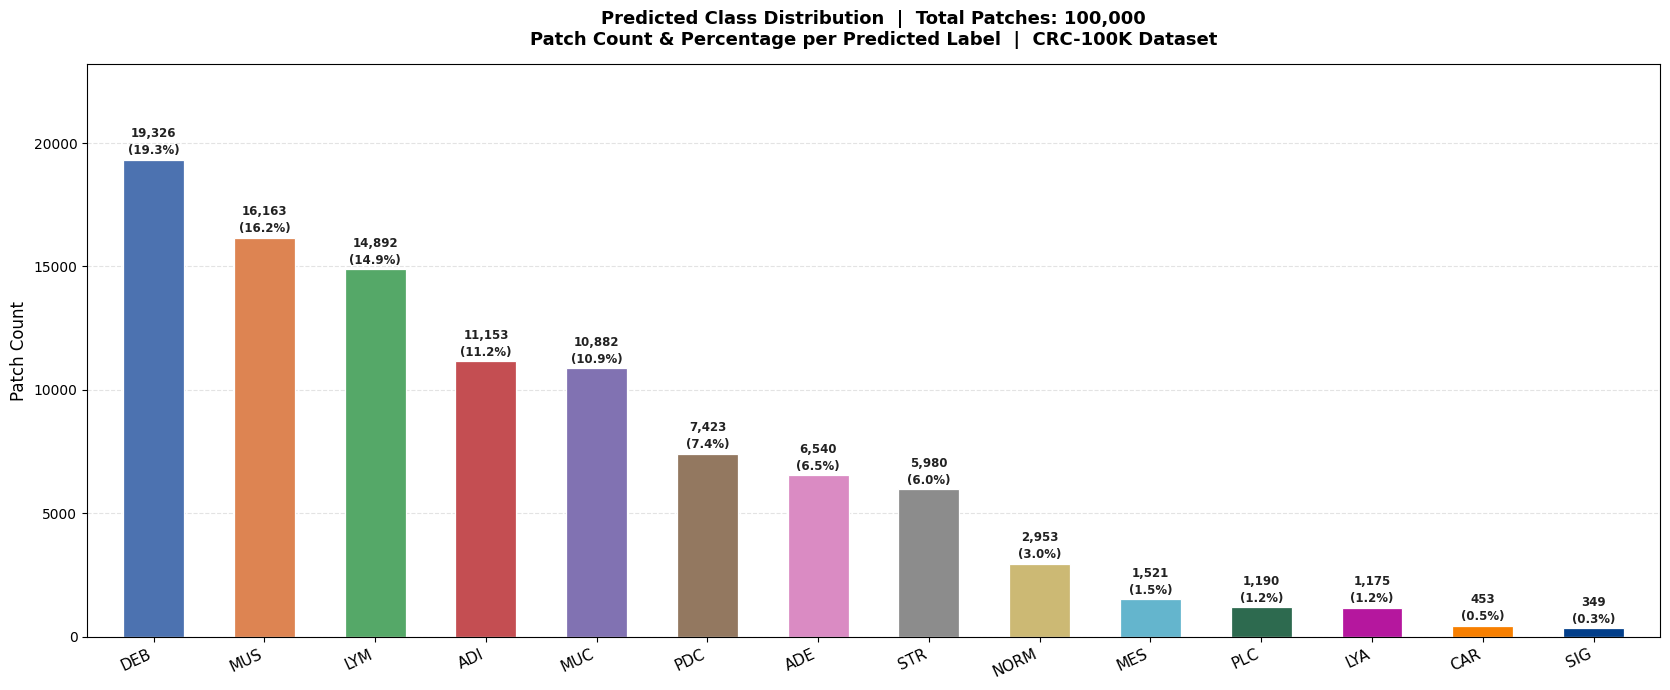

In [6]:
# If running standalone, just load the raw CSV yourself:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import torch
from PIL import Image
from tqdm import tqdm
from pathlib import Path
from conch.open_clip_custom import create_model_from_pretrained
from conch.downstream.zeroshot_path import zero_shot_classifier

# ═══════════════════════════════════════════════════════════════════════════════
# CONFIGURATION  — update these paths
# ═══════════════════════════════════════════════════════════════════════════════
MAIN_FOLDER     = r"D:\Aamir Gulzar\dataset\CRC100K\NCT-CRC-HE-100K-NONORM"
CHECKPOINT_PATH = r"D:\Aamir Gulzar\KSA_project2\Cancer-detection-classifier\slide_aggregation\caption_generation\checkpoints\CONCH\pytorch_model.bin"
PROMPT_FILE     = r"D:\Aamir Gulzar\KSA_project2\Cancer-detection-classifier\slide_aggregation\caption_generation\config_files\Custom_prompts_all_per_class.json"
WEIGHTS_PATH    = r"D:\Aamir Gulzar\KSA_project2\Cancer-detection-classifier\slide_aggregation\caption_generation\classifier_weights\Conch_zeroshot_weights.pt"

OUTPUT_DIR      = r"Results\CRC100K_ZeroShot_Statistics"
RAW_CSV         = os.path.join(OUTPUT_DIR, "crc100k_raw_predictions.csv")
STATS_CSV       = os.path.join(OUTPUT_DIR, "patch_class_statistics.csv")
CHART_PNG       = os.path.join(OUTPUT_DIR, "patch_class_statistics.png")
HEATMAP_PNG     = os.path.join(OUTPUT_DIR, "gt_to_pred_heatmap.png")
CHART_2_PNG       = os.path.join(OUTPUT_DIR, "patch_class_statistics_2.png")

FORCE_IMAGE_SIZE = 224
SAVE_EVERY       = 10_000

# ═══════════════════════════════════════════════════════════════════════════════
# CLASS DEFINITIONS
# ═══════════════════════════════════════════════════════════════════════════════
# 9 CRC-100K ground-truth classes (rows of the heatmap)
GT_CLASSES = ["ADI", "BACK", "DEB", "LYM", "MUC", "MUS", "NORM", "STR", "TUM"]

# 14 zero-shot predicted classes (columns of the heatmap)
PRED_CLASSES = ["ADI", "DEB", "LYM", "PLC", "LYA", "MUC", "MUS", "NORM",
                "ADE", "STR", "MES", "CAR", "PDC", "SIG"]

# ── Verdict maps ──────────────────────────────────────────────────────────────
CORRECT_MAP = {
    "ADI":  {"ADI"},
    "BACK": set(),
    "DEB":  {"DEB"},
    "LYM":  {"LYM"},
    "MUC":  {"MUC"},
    "MUS":  {"MUS"},
    "NORM": {"NORM"},
    "STR":  {"STR"},
    "TUM":  set(),
}

SUBTYPE_MAP = {
    "ADI":  set(),
    "BACK": set(),
    "DEB":  set(),
    "LYM":  {"LYA"},
    "MUC":  set(),
    "MUS":  {"MES"},
    "NORM": set(),
    "STR":  {"MES"},
    "TUM":  {"CAR", "PDC", "ADE", "SIG"},
}


def get_verdict(gt_label, pred_label):
    """Return 'correct', 'correct_subtype', or 'incorrect'."""
    gt   = gt_label.upper()
    pred = pred_label.upper()
    if pred in CORRECT_MAP.get(gt, set()):
        return "correct"
    if pred in SUBTYPE_MAP.get(gt, set()):
        return "correct_subtype"
    return "incorrect"

df = pd.read_csv(RAW_CSV)

BAR_PALETTE = [
    "#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2",
    "#937860", "#DA8BC3", "#8C8C8C", "#CCB974", "#64B5CD",
    "#2d6a4f", "#b5179e", "#f77f00", "#023e8a",
]

# ── Compute per predicted-class statistics ────────────────────────────────────
total_patches = len(df)

stats = (
    df.groupby("pred_label")
    .agg(
        patch_count=("pred_label", "count"),
        mean_score=("score", "mean"),
        std_score=("score", "std"),
        min_score=("score", "min"),
        max_score=("score", "max"),
    )
    .reset_index()
    .sort_values("patch_count", ascending=False)
    .reset_index(drop=True)
)
stats["percentage"] = (stats["patch_count"] / total_patches * 100).round(2)
for col in ["mean_score", "std_score", "min_score", "max_score"]:
    stats[col] = stats[col].round(4)

print(stats[["pred_label", "patch_count", "percentage"]].to_string(index=False))

# ── Plot ──────────────────────────────────────────────────────────────────────
labels  = stats["pred_label"].tolist()
counts  = stats["patch_count"].tolist()
pcts    = stats["percentage"].tolist()

x      = np.arange(len(labels))
colors = [BAR_PALETTE[i % len(BAR_PALETTE)] for i in range(len(labels))]
bar_w  = 0.55
y_max  = max(counts)

fig, ax = plt.subplots(figsize=(max(10, len(labels) * 1.2), 7))
ax.bar(x, counts, width=bar_w, color=colors, edgecolor="white", linewidth=0.9, zorder=2)

for xi, cnt, pct in zip(x, counts, pcts):
    ax.text(
        xi,
        cnt + y_max * 0.005,
        f"{int(cnt):,}\n({pct:.1f}%)",
        ha="center", va="bottom",
        fontsize=8.5, fontweight="bold",
        color="#222222", zorder=3, linespacing=1.4,
    )

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11, rotation=25, ha="right")
ax.set_ylabel("Patch Count", fontsize=12)
ax.set_ylim(0, y_max * 1.20)
ax.set_xlim(-0.6, len(labels) - 0.4)
ax.set_title(
    f"Predicted Class Distribution  |  Total Patches: {total_patches:,}\n"
    f"Patch Count & Percentage per Predicted Label  |  CRC-100K Dataset",
    fontsize=13, fontweight="bold", pad=14,
)
ax.yaxis.grid(True, linestyle="--", alpha=0.35, zorder=0)
ax.set_axisbelow(True)
fig.tight_layout()

# Optional: save to file
fig.savefig(CHART_2_PNG, dpi=150, bbox_inches="tight")

plt.show()